# Short Report

## Data
The word-level LSTM was trained on the provided story, it was divided in a 90-10 split for validation. The vocabulary was fixed and stored with the checkpoint to ensure consistent token mapping during evaluation.

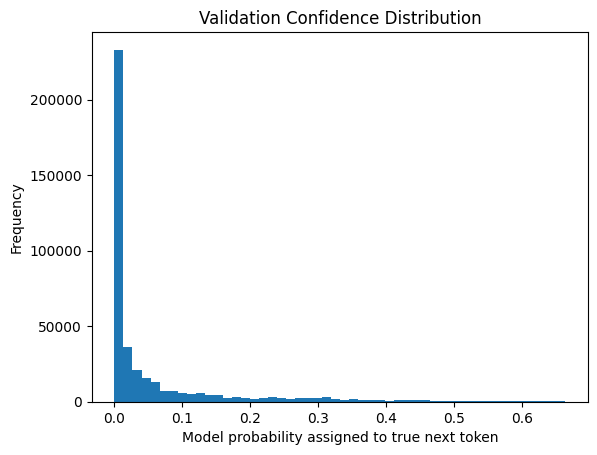

**Figure 1** shows the validation confidence distribution for the LSTM, the probability for true next token is near zero which means that the model is not confident in its choice for the next true token

## Quantitative Results (LSTM)

Validation loss/token: 5.6184

Validation perplexity: 275.44

Top-1 accuracy: 16.42%

Top-5 accuracy: 35.05%

The perplexity of 275 shows that the the model is on average choosing from about 275 different words that have equal probability of being the next token. For a word level model trained on a single story this is a lot of uncertainty which is expected.
The top-1 accuracy shows limited precision in next-token prediction but top-5 shows that the correct token is a lot of the times ranked among plausible tokens.

## Qualitative Comparison
### Gemini Output

The Gemini continuation demonstrates:
- Consistent characterisation of Poirot and Hastings
- Stylistic alignment with Agatha Christie's writing
- Coherent narrative progression
- Logical development of a clue (the misplaced teaspoon)

Sentences are grammatically correct and semantically consistent, they even maintain a narrative which preserves tone and has a structure.

LSTM Output

The LSTM continuation exhibits:
- Severe grammatical breakdown
- Loss of syntactic structure
- Repetition and malformed token spacing
- Inconsistent subject–verb agreement
- No stable narrative progression

The model is not consistent and fails to form any sort of coherence. The tokens are preserved but the structure is all over the place.

## Interpretation
| Aspect                | LSTM (Single Book)      | Gemini (Large LLM)        |
|----------------------|-------------------------|----------------------------|
| Training data scale  | Single novel            | Large-scale web corpus     |
| Model capacity       | Small recurrent network | Large transformer          |
| Long-range coherence | Very limited            | Strong                     |
| Grammatical control  | Weak                    | Strong                     |
| Narrative planning   | Absent                  | Structured                 |


Due to the large scale and extreme training Gemini has had it outperforms the LSTM by a huge margin. The LSTM would benefit by training on a larger dataset (a whole book or multiple books) to reduce perplexity and form more coherent sentences.

### Prompt given to Gemini

```
You are being asked to generate text in the style of a literary detective novel.

Continue the following prompt in approximately 200–300 words:

I was standing at the window of Poirot's rooms when he suddenly turned toward me and said,

Write the continuation in a style consistent with early 20th-century detective fiction by Agatha Christie. Maintain coherent narrative progression, consistent character behaviour, and logical development of events. Avoid meta commentary.
```

### Gemini's Response

```
I was standing at the window of Poirot's rooms when he suddenly turned toward me and said, 'Hastings, mon ami, have you ever considered the profound significance of the misplaced teaspoon?'

I blinked, momentarily distracted from the grey London drizzle. 'A teaspoon, Poirot? I can’t say I have. I was rather more concerned with the vanishing of the Marchester diamonds.'

'Precisely!' Poirot cried, waving his hands with a flourish that threatened the stability of his perfectly symmetrical moustache. 'The diamonds are the thunder, loud and distracting. But the teaspoon—ah, that is the quiet lightning! One does not simply find a silver Apostle spoon in the umbrella stand of a gentleman’s club unless the world has tilted on its axis.'

He paced the length of the hearthrug, his patent leather shoes clicking with rhythmic precision. He stopped to adjust a small porcelain figurine that had migrated a fraction of an inch to the left.

'You see, Hastings, the human mind is a creature of habit. When a habit is broken—even a small, culinary habit—it betrays a disturbance in the grey cells of the perpetrator. Someone was agitated. Someone was in a great hurry. And that someone, despite their haste, felt the need to conceal a piece of cutlery.'

'But surely it was just a prank,' I suggested, though I knew the futility of such a remark.

'A prank?' Poirot sighed, a look of profound disappointment clouding his face. 'You are an incurable romantic. No, it is a clue. A beautiful, shining clue that points directly to the heart of this little comedy. Fetch your hat, Hastings. We must visit the scene of this "prank" before the trail grows cold—or before someone decides to wash the dishes!

```


### Trained LSTM response

```
i was standing at the window of poirot' s rooms when he suddenly turned toward me and said." i cried, you, with my prime way in his time. i can know he have not all a little little."" oh, mr." you must think a two - -" there' t a face?"" yes' t so at a few." what is that?"" no, it' m one from my friend down for a moment? the doctor is been them before"" it are you, i was not at the same of the police that with poirot was so to her, but the other, of this own, who' m do of you? now as that we did in the case. we understand me that my eyes of the body and then he was going, the door seemed a police car of and his room will, we, it' s good man, or the young thing was - there is to been - i will so
```

In [ ]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

# Base folders
BASE = Path("/content/drive/My Drive/Deep Learning Assignment Final/Part 2")
DATA_DIR = BASE / "Data"
CKPT_DIR = BASE / "_checkpoints" / "word_lstm_20260219_155442"

# Dataset file
TEXT_PATH = DATA_DIR / "61262-0.txt"

MODEL_PATH = CKPT_DIR / "model.pt"
META_PATH  = CKPT_DIR / "meta.json"
STOI_PATH  = CKPT_DIR / "stoi.json"
ITOS_PATH  = CKPT_DIR / "itos.json"

# Sanity checks
assert DATA_DIR.exists(), f"Missing DATA_DIR: {DATA_DIR}"
assert CKPT_DIR.exists(), f"Missing CKPT_DIR: {CKPT_DIR}"
assert TEXT_PATH.exists(), f"Missing TEXT_PATH: {TEXT_PATH}"
assert MODEL_PATH.exists(), f"Missing model.pt: {MODEL_PATH}"
assert META_PATH.exists(), f"Missing meta.json: {META_PATH}"

print("DATA_DIR :", DATA_DIR)
print("CKPT_DIR :", CKPT_DIR)
print("TEXT_PATH:", TEXT_PATH)
print("Found model/meta")

print("Has stoi.json:", STOI_PATH.exists())
print("Has itos.json:", ITOS_PATH.exists())

Mounted at /content/drive
DATA_DIR : /content/drive/My Drive/Deep Learning Assignment Final/Part 2/Data
CKPT_DIR : /content/drive/My Drive/Deep Learning Assignment Final/Part 2/_checkpoints/word_lstm_20260219_155442
TEXT_PATH: /content/drive/My Drive/Deep Learning Assignment Final/Part 2/Data/61262-0.txt
Found model/meta
Has stoi.json: True
Has itos.json: True


In [ ]:
import json
import math
import random
import re
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [ ]:
# Load metadata
with open(META_PATH, "r") as f:
    meta = json.load(f)

print("Full meta.json contents:\n")
for k, v in meta.items():
    print(f"{k}: {v}")

Full meta.json contents:

model: LSTMLM
vocab_size: 5943
block_size: 128


In [ ]:
# Load vocabulary mappings
with open(STOI_PATH, "r") as f:
    stoi = json.load(f)

with open(ITOS_PATH, "r") as f:
    itos = json.load(f)

vocab_size = len(itos)
print("\nVocab size:", vocab_size)

# Extract block size (must exist)
block_size = int(meta["block_size"])
print("block_size:", block_size)

# Store meta for later model reconstruction


Vocab size: 5943
block_size: 128


In [ ]:
state_dict = torch.load(MODEL_PATH, map_location="cpu")

# Embedding size from embedding matrix
d_emb = state_dict["emb.weight"].shape[1]

# LSTM hidden size from weight_ih_l0: shape (4*d_hid, d_emb)
w_ih_l0 = state_dict["lstm.weight_ih_l0"]
d_hid = w_ih_l0.shape[0] // 4

# Number of layers from presence of weight_ih_l{k}
layer_keys = [k for k in state_dict.keys() if k.startswith("lstm.weight_ih_l")]
layer_ids = sorted({int(k.split("lstm.weight_ih_l")[1]) for k in layer_keys})
n_layers = len(layer_ids)

# Dropout cannot be recovered reliably from state_dict; set to 0.0 for evaluation (model.eval() disables dropout anyway)
dropout = 0.0

print("Inferred architecture:")
print("d_emb   :", d_emb)
print("d_hid   :", d_hid)
print("n_layers:", n_layers)
print("vocab_size (itos):", len(itos))

Inferred architecture:
d_emb   : 192
d_hid   : 384
n_layers: 2
vocab_size (itos): 5943


In [ ]:
def strip_gutenberg_boilerplate(text: str) -> str:
    start_markers = [
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "***START OF THIS PROJECT GUTENBERG EBOOK",
        "*** START OF THE PROJECT GUTENBERG EBOOK",
    ]
    end_markers = [
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "***END OF THIS PROJECT GUTENBERG EBOOK",
        "*** END OF THE PROJECT GUTENBERG EBOOK",
    ]

    start_idx = 0
    for m in start_markers:
        i = text.find(m)
        if i != -1:
            start_idx = i
            break

    end_idx = len(text)
    for m in end_markers:
        i = text.find(m)
        if i != -1:
            end_idx = i
            break

    return text[start_idx:end_idx]

In [ ]:
def normalize_text(s: str) -> str:
    s = s.replace("’", "'").replace("‘", "'")
    s = s.replace("“", '"').replace("”", '"')
    s = s.replace("—", "-").replace("–", "-")
    s = s.replace("\ufeff", "")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

In [ ]:
ANCHOR = "i was standing at the window of poirot's rooms"
TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def tokenize(s: str):
    return TOKEN_RE.findall(s)

raw = TEXT_PATH.read_text(encoding="utf-8", errors="ignore")
story = strip_gutenberg_boilerplate(raw)
clean = normalize_text(story).lower()

anchor_idx = clean.find(ANCHOR)
assert anchor_idx != -1, "Anchor not found in cleaned text; dataset version differs from training."

narr = clean[anchor_idx:].strip()
tokens = tokenize(narr)

print("Chars (narr):", len(narr))
print("Tokens:", len(tokens))
print("Preview:", " ".join(tokens[:60]))

Chars (narr): 293659
Tokens: 68227
Preview: i was standing at the window of poirot ' s rooms looking out idly on the street below . " that ' s queer , " i ejaculated suddenly beneath my breath . " what is , _mon ami_ ? " asked poirot placidly , from the depths of his comfortable chair . " deduce , poirot , from the


In [ ]:
# Tail hold-out split (last 10% tokens as validation), as used in training
val_frac = 0.10
n_total = len(tokens)
n_val = int(n_total * val_frac)

train_tokens = tokens[:-n_val]
val_tokens   = tokens[-n_val:]

# Encode with checkpoint vocabulary to guarantee identical token ids
UNK_ID = stoi.get("<UNK>", 1)

def encode(tok_list):
    return [stoi.get(t, UNK_ID) for t in tok_list]

train_ids = encode(train_tokens)
val_ids   = encode(val_tokens)

print("Train tokens:", len(train_tokens), " Train ids:", len(train_ids))
print("Val tokens:  ", len(val_tokens),   " Val ids:  ", len(val_ids))

Train tokens: 61405  Train ids: 61405
Val tokens:   6822  Val ids:   6822


In [ ]:
# Dataset: next-token prediction with fixed block size
from torch.utils.data import Dataset, DataLoader

class LMDataset(Dataset):
    def __init__(self, ids, block_size: int):
        self.ids = torch.tensor(ids, dtype=torch.long)
        self.block_size = block_size

    def __len__(self):
        return max(0, len(self.ids) - self.block_size - 1)

    def __getitem__(self, idx):
        x = self.ids[idx : idx + self.block_size]
        y = self.ids[idx + 1 : idx + self.block_size + 1]
        return x, y

train_ds = LMDataset(train_ids, block_size)
val_ds   = LMDataset(val_ids, block_size)

# Batch size is not stored in meta.json for this run; 64 matches the training notebook default
batch_size = 64
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print("Val batches:", len(val_loader))

Val batches: 105


In [ ]:
# ===== Cell 7 (Fixed): Define model + load weights (matches checkpoint keys) =====

class LSTMLM(nn.Module):
    def __init__(self, vocab_size, d_emb, d_hid, n_layers, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb)
        self.lstm = nn.LSTM(
            input_size=d_emb,
            hidden_size=d_hid,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True,
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d_hid, vocab_size)  # name matches saved state_dict

    def forward(self, x, hidden=None):
        x = self.emb(x)
        out, hidden = self.lstm(x, hidden)
        out = self.drop(out)
        logits = self.head(out)
        return logits, hidden

model = LSTMLM(vocab_size=len(itos), d_emb=d_emb, d_hid=d_hid, n_layers=n_layers, dropout=0.5).to(device)

# Reload strictly now that names match
model.load_state_dict(state_dict, strict=True)

model.eval()
print("Model loaded (strict=True) and set to eval().")

Model loaded (strict=True) and set to eval().


In [ ]:
@torch.no_grad()
def eval_loss_per_token(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)  # (B,T,V)
        B, T, V = logits.shape

        loss = F.cross_entropy(
            logits.reshape(-1, V),
            yb.reshape(-1),
            reduction="sum"
        )

        total_loss += float(loss)
        total_tokens += yb.numel()

    return total_loss / max(1, total_tokens)

loss_tok = eval_loss_per_token(model, val_loader)
ppl = math.exp(min(loss_tok, 50.0))  # clamp for numerical safety

print(f"Validation loss/token: {loss_tok:.4f}")
print(f"Validation perplexity: {ppl:.2f}")

Validation loss/token: 5.6184
Validation perplexity: 275.44


In [ ]:
@torch.no_grad()
def eval_topk_accuracy(model, loader, topk=(1, 5)):
    model.eval()
    correct = {k: 0 for k in topk}
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)  # (B,T,V)
        B, T, V = logits.shape

        logits = logits.reshape(-1, V)
        y = yb.reshape(-1)

        total += y.numel()
        for k in topk:
            pred = logits.topk(k, dim=-1).indices  # (N,k)
            correct[k] += int((pred == y.unsqueeze(-1)).any(dim=-1).sum())

    return {f"top{k}": correct[k] / total for k in topk}

accs = eval_topk_accuracy(model, val_loader, topk=(1, 5))
print("Validation accuracies:", accs)

Validation accuracies: {'top1': 0.1641698883161512, 'top5': 0.35045943523083817}


In [ ]:
def decode(id_list):
    return [itos[i] for i in id_list]

In [ ]:
def detokenize(tok_list):
    out = []
    no_space_before = {".", ",", "!", "?", ";", ":", ")", '"', "'"}
    no_space_after  = {"(", '"'}
    for t in tok_list:
        if not out:
            out.append(t)
            continue
        if t in no_space_before:
            out[-1] = out[-1] + t
        elif out[-1] in no_space_after:
            out[-1] = out[-1] + t
        else:
            out.append(" " + t)
    return "".join(out)

In [ ]:
def sample_next_from_logits(logits, temperature=0.8, top_k=40):
    logits = logits / max(float(temperature), 1e-6)
    probs = torch.softmax(logits, dim=-1)

    if top_k and top_k > 0:
        v, idx = torch.topk(probs, k=min(int(top_k), probs.size(-1)))
        mask = torch.zeros_like(probs)
        mask[idx] = v
        probs = mask / mask.sum()

    return torch.multinomial(probs, 1).item()

In [ ]:
def apply_repetition_penalty(logits, generated_ids, penalty=1.15, window=128):
    if penalty <= 1.0:
        return logits

    recent = generated_ids[-window:]
    counts = Counter(recent)

    logits = logits.clone()
    for tok_id, _ in counts.items():
        if logits[tok_id] > 0:
            logits[tok_id] /= penalty
        else:
            logits[tok_id] *= penalty

    return logits

In [ ]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens=180, temperature=0.8, top_k=40, repetition_penalty=1.15):
    prompt = prompt.strip().lower()
    prompt_tokens = tokenize(prompt)

    if len(prompt_tokens) == 0:
        return ""

    # Encode prompt tokens using checkpoint stoi
    context = [stoi.get(t, UNK_ID) for t in prompt_tokens]
    generated = list(context)

    # Prime hidden state using the prompt context (truncate to block_size)
    hidden = None
    ctx = torch.tensor([generated[-block_size:]], dtype=torch.long, device=device)
    logits, hidden = model(ctx, hidden)

    for _ in range(max_new_tokens):
        last_logits = logits[0, -1]  # (V,)
        last_logits = apply_repetition_penalty(last_logits, generated, penalty=repetition_penalty)
        nxt = sample_next_from_logits(last_logits, temperature=temperature, top_k=top_k)

        generated.append(nxt)

        x = torch.tensor([[nxt]], dtype=torch.long, device=device)
        logits, hidden = model(x, hidden)

    return detokenize(decode(generated))

# Quick sanity check
print(generate("poirot", max_new_tokens=80))

poirot' s be." we have it was a head. my friend' ve been been a little to them, but she am with the car of the moment of every, of my man would no time in two as and i can was be it to so me from once on a room: then is at a old thing the doctor would?" you can not to be his head, he will


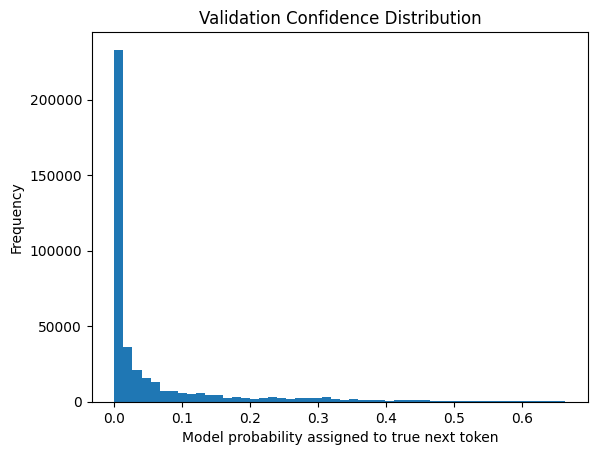

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_confidences(model, loader, max_batches=50):
    model.eval()
    confidences = []

    for i, (xb, yb) in enumerate(loader):
        if i >= max_batches:
            break

        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        probs = torch.softmax(logits, dim=-1)

        B, T, V = probs.shape
        probs = probs.reshape(-1, V)
        y = yb.reshape(-1)

        true_probs = probs[torch.arange(len(y)), y]
        confidences.extend(true_probs.cpu().tolist())

    return confidences

confidences = collect_confidences(model, val_loader)

plt.figure()
plt.hist(confidences, bins=50)
plt.xlabel("Model probability assigned to true next token")
plt.ylabel("Frequency")
plt.title("Validation Confidence Distribution")
plt.show()

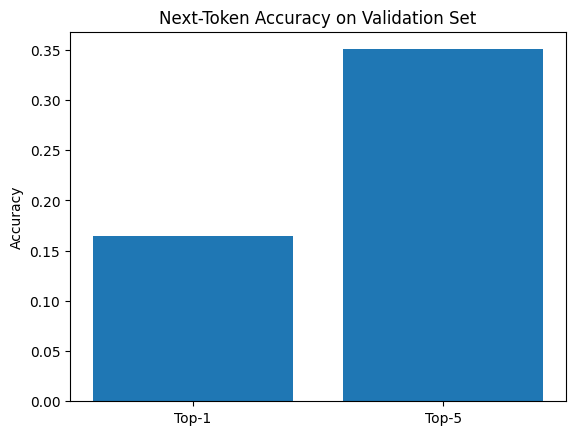

In [ ]:
plt.figure()
plt.bar(["Top-1", "Top-5"], [accs["top1"], accs["top5"]])
plt.ylabel("Accuracy")
plt.title("Next-Token Accuracy on Validation Set")
plt.show()

## Interactive Loop for testing

In [ ]:
def interactive_loop():
    print("Enter a prompt (empty line to stop).")
    while True:
        prompt = input("\nPrompt> ").strip()
        if prompt == "":
            print("Stopped.")
            break

        out = generate(
            prompt,
            max_new_tokens=180,
            temperature=0.8,
            top_k=40,
            repetition_penalty=1.15
        )

        print("\n--- Generated ---\n")
        print(out)

interactive_loop()

Enter a prompt (empty line to stop).

--- Generated ---

it was half - past i' ll have a one, and as he thought." i should a small of a man, she must know the head," the doctor of the diamond will so to the young day. we have been them." poirot?"" that they is the first, she, i am about one!" he' t found him, the two of my matter, he had been his minutes, and a hand was the moment. there could not think that the case was his case, but i don of the woman with a face on the few out. if you was been at a same, which poirot had s good right from him. he would see in the room."" is what that i do all this." i did not be him." i had all him. - it seemed be, or you were so."" oh. mr."" i

--- Generated ---

lord yardly sprang up with an oath. i accompanied him, my heart beating wildly. the chinaman again! the side door in question was a small one in the angle of the wall, not more than a dozen yards from the scene of the tragedy. as we reached it, i gave a cry. there, just short of the thresh